<a href="https://colab.research.google.com/github/Bilra-Hkr/BigData26_B_2411533007_DerielChaerahman/blob/main/Praktikum3/BD_P03_2411533007_DerielChaerahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum

In [48]:
# Import library
import sys, time, json, sqlite3, gc, os
import pandas as pd, numpy as np, psutil

# Cek instalasi library
for nama in ["pandas", "numpy", "pyarrow", "request", "sklearn", "sqlalchemy"]:
  try:
    mode = __import__(nama)
    print(f"{nama:11s}: {mode.__version__}")
  except ImportError:
    print(f"{nama:11s}: BELUM TERPASANG")

# connect to google drive
from google.colab import drive
drive.mount("/content/drive")
DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
  os.makedirs(d, exist_ok=True)

# Fungsi ukur biaya komputasi (waktu dan memori)
proses = psutil.Process(os.getpid())
catatan = []     # menyimpan hasil pengukuran
def rss_mb():
    return proses.memory_info().rss / 1024**2
def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

# log sumber data (lineage)
lineage = []
def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
  lineage.append({
      "sumber": nama, "asal": asal,
      "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
      "jumlah_baris": jumlah_baris, "keterangan": keterangan,
  })
  print(f"[lineage] {nama}: {jumlah_baris:,} baris")


pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
request    : BELUM TERPASANG
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# K-2. Akuisisi 1 — Unduhan Berkala yang Tahan Gagal

In [49]:
import requests, shutil
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    r.raw.decode_content = True
                    shutil.copyfileobj(r.raw, f)
                if os.path.getsize(sementara) == 0:
                    raise IOError("berkas kosong")
                os.replace(sementara, tujuan)  # atomik
                return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)  # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()

cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s | RSS +0.0 MB
cache ditemukan: taxi_zone_lookup.csv
[unduh zona] 0.00 s | RSS +0.0 MB
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 2.79 s | RSS +256.7 MB
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


# K-3. Akuisisi 2 — Memanggil API JSON

In [50]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:  # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):  # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()  # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespon dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m": "suhu_c",
                              "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.85 s | RSS +0.0 MB
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


# K-4. Jalur Cadangan bila Internet Diblokir

In [51]:
# def cuaca_sintetis(mulai="2023-01-01", selesai="2023-01-31", seed=7):
#     jam = pd.date_range(mulai, pd.Timestamp(selesai) + pd.Timedelta("23h"), freq="h")
#     rng = np.random.default_rng(seed)
#     return pd.DataFrame({
#         "jam_mulai": jam,
#         "suhu_c": np.round(rng.normal(3, 5, len(jam)), 1),
#         "hujan_mm": np.round(rng.gamma(0.4, 0.8, len(jam)), 2),
#     })

# Pakai hanya jika K-3 gagal:
# cuaca = cuaca_sintetis()
# catat_sumber("cuaca", "sintetis", len(cuaca), "PENGGANTI - bukan data nyata")

# K-5. Akuisisi 3 — Basis Data SQLite dengan Pemuatan Bertahap

In [52]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                       "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
FROM trip_operasional
WHERE total_amount > 0
GROUP BY payment_type
ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


# K-6. Profiling Kualitas Data pada Enam Dimensi

In [53]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])
aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}
laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


# K-7. Nilai Hilang dan Duplikat

In [54]:
KOL = "passenger_count"
asli = trip[KOL].copy()
print(f"persen hilang {KOL}: {round(100 * asli.isna().mean(), 3)}%")

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

strategi = {
    "1_dibuang"      : asli.dropna(),
    "2_isi_median"   : asli.fillna(asli.median()),
    "3_isi_modus"    : asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(
                           trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {
        "strategi": nama,
        "n"       : len(s),
        "mean"    : round(s.mean(), 4),
        "median"  : s.median(),
        "std"     : round(s.std(), 4),
    }
    for nama, s in strategi.items()
])
print("\nPerbandingan Strategi Pengisian")
print(banding.to_string(index=False))

#  Terapkan strategi terpilih
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(
    trip.groupby("jam")[KOL].transform("median")
)
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

#  Duplikat
KUNCI = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID", "total_amount",
]

dup_penuh = trip.duplicated().sum()
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"\nduplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"baris: {sebelum:,} → {len(trip):,} ({sebelum-len(trip):,} dibuang)")

persen hilang passenger_count: 2.339%

Perbandingan Strategi Pengisian
       strategi       n   mean  median    std
      1_dibuang 2995023 1.3625     1.0 0.8961
   2_isi_median 3066766 1.3541     1.0 0.8873
    3_isi_modus 3066766 1.3541     1.0 0.8873
4_median_perjam 3066766 1.3541     1.0 0.8873

duplikat penuh: 0 | duplikat pada kunci: 1
baris: 3,066,766 → 3,066,765 (1 dibuang)


Note Penanganan Nilai Hilang dan Duplikat :
- `passenger_count` menggunakan strategi 4 (median per jam) karena nilai hilang kemungkinan MAR, bergantung pada jam/waktu. Kolom penanda `_hilang` ditambahkan agar informasi kekosongannya tidak hilang.
- Duplikat dibuang berdasarkan lima kolom kunci. Definisi kunci dipilih agar tidak membuang perjalanan berbeda yang kebetulan punya tarif sama.

# K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu

In [55]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (
    (trip["trip_distance"].between(0.01, 100)) &
    (trip["durasi_menit"].between(1, 180)) &
    (trip["total_amount"] > 0)
)
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# Join 1: tabel zona (dimensi)
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")  # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# Join 2: tabel pembayaran dari basis data
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                     on="payment_type", how="left", validate="many_to_one")

# Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu)
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


# K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran

In [56]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])      # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


# K-10. Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi

In [57]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]
    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
          .drop(columns="LocationID")
          .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                 on="payment_type", how="left", validate="many_to_one"))
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 8.12 s | RSS +337.9 MB
[tulis parquet berpartisi] 3.29 s | RSS +380.3 MB
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

# K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)

In [58]:
!pip install -q pyspark==3.5.1

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
                (F.unix_timestamp("tpep_dropoff_datetime")
                 - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                     "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),  # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()  # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

[spark: hitung baris bersih] 14.42 s | RSS +0.0 MB
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#841, tpep_dropoff_datetime#842, passenger_count#1085, trip_distance#1087, PULocationID#847L, DOLocationID#848L, payment_type#1089L, fare_amount#1091, tip_amount#1093, total_amount#856, durasi_menit#1095, Borough#890]
   +- BroadcastHashJoin [PULocationID#847L], [LocationID#889L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#848L, tpep_dropoff_datetime#842, PULocationID#847L, total_amount#856, tpep_pickup_datetime#841], functions=[first(passenger_count#843, false), first(trip_distance#844, false), first(payment_type#849L, false), first(fare

# O. Analisis Hasil

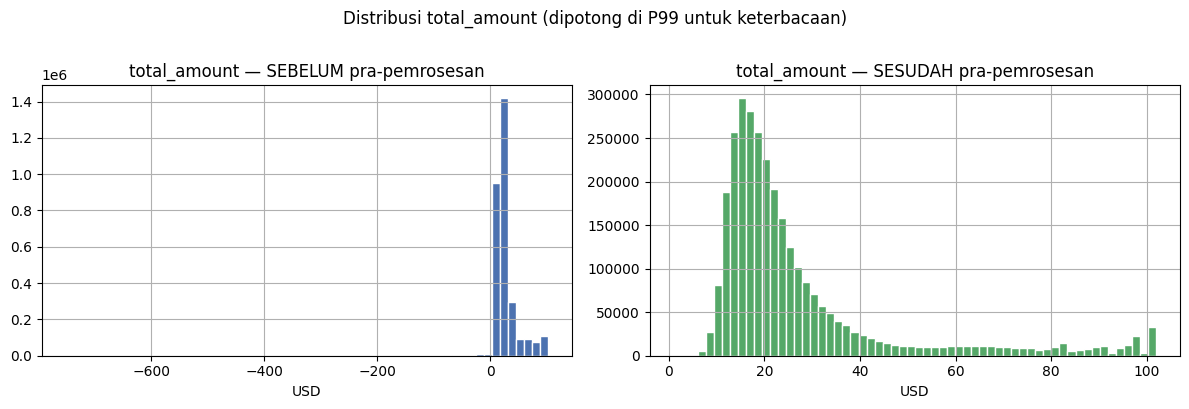

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
lim = trip["total_amount"].quantile(0.99)

trip["total_amount"].clip(upper=lim).hist(
    bins=60, ax=axes[0], color="#4c72b0", edgecolor="white")
axes[0].set_title("total_amount — SEBELUM pra-pemrosesan")
axes[0].set_xlabel("USD")

bersih["total_amount"].clip(upper=lim).hist(
    bins=60, ax=axes[1], color="#55a868", edgecolor="white")
axes[1].set_title("total_amount — SESUDAH pra-pemrosesan")
axes[1].set_xlabel("USD")

plt.suptitle("Distribusi total_amount (dipotong di P99 untuk keterbacaan)", y=1.01)
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/distribusi_total_amount.png", dpi=120, bbox_inches="tight")
plt.show()

# P. Studi Kasus
Menyiapkan data untuk tim penetapan harga dinamis

In [60]:
# Tabel analitik per borough per jam
tabel_analitik = (
    bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(
        jumlah_perjalanan=("total_amount",    "size"),
        rata_tarif_per_mil=("tarif_per_mil",  "median"),
        rata_kecepatan    =("kecepatan_mph",  "median"),
        suhu_c            =("suhu_c",         "first"),
        hujan             =("hujan",          "max"),
    )
    .reset_index()
)
# Ambang minimum: kelompok yang terlalu kecil tidak bisa disimpulkan
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

# point 2: Tabel perbandingan hujan vs tidak hujan per borough
tabel_hujan = (
    tabel_analitik
    .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
    .median()
    .unstack()
    .round(3)
)
tabel_hujan.columns = ["Tidak Hujan (0)", "Hujan (1)"]
tabel_hujan["Selisih"] = (tabel_hujan["Hujan (1)"] - tabel_hujan["Tidak Hujan (0)"]).round(3)
tabel_hujan["Naik?"] = tabel_hujan["Selisih"].apply(lambda x: "✓" if x > 0 else "✗")
print(tabel_hujan.to_string())

# Point 1 : Simpan tabel analitik sebagai parquet
PATH_ANALITIK = f"{DIR_SIMPAN}/tabel_analitik.parquet"
tabel_analitik.to_parquet(PATH_ANALITIK, index=False)
print(f"\n✓ Tabel analitik disimpan: {PATH_ANALITIK}")

              Tidak Hujan (0)  Hujan (1)  Selisih Naik?
borough_naik                                           
Brooklyn                6.943      7.655    0.712     ✓
Manhattan              10.527     11.400    0.873     ✓
Queens                  5.453      5.636    0.183     ✓
Unknown                 8.726      9.886    1.160     ✓

✓ Tabel analitik disimpan: /content/drive/MyDrive/BigData/Praktikum3/tabel_analitik.parquet


In [61]:
# point 1 : kamus_data.md
kamus = """# Kamus Data — tabel_analitik

| Kolom | Tipe | Satuan | Sumber | Cara Hitung | Penanganan Null |
|---|---|---|---|---|---|
| borough_naik | string | — | taxi_zone_lookup.csv | join PULocationID | baris tanpa match dieksklusi |
| jam_mulai | datetime | jam | tpep_pickup_datetime | floor('h') | — |
| jumlah_perjalanan | int | perjalanan | trips | COUNT per grup | — |
| rata_tarif_per_mil | float | USD/mil | trips | median(total_amount/trip_distance) | grup < 30 perjalanan dibuang |
| rata_kecepatan | float | mph | trips | median(trip_distance/(durasi_menit/60)) | sama |
| suhu_c | float | °C | Open-Meteo API | first() per jam-borough | diisi 0 bila API tidak ada data |
| hujan | int8 | 0/1 | Open-Meteo API | max(hujan_mm > 0.1) per grup | diisi 0 |

## Batasan
1. Median dipakai menggantikan mean karena distribusi tarif per mil sangat miring ke kanan.
2. Cuaca diukur di satu titik koordinat (40.71°N, 74.00°W) untuk seluruh kota — variasi spasial tidak tertangkap.
3. Korelasi tarif–hujan tidak membuktikan kausalitas; jam sibuk bisa bersamaan dengan hujan.
4. Kelompok < 30 perjalanan dibuang — borough kecil (Staten Island) bisa kehilangan banyak jam.
"""

with open(f"{DIR_SIMPAN}/kamus_data.md", "w") as f:
    f.write(kamus)
print("✓ kamus_data.md tersimpan.")
print("\n** Pembaruan otomatis bulanan:")
print("Ganti URL_TRIP ke bulan berikutnya, jalankan ulang pipeline(), append ke direktori "
      "trips_bersih/ yang sama. Partisi per borough_naik sudah memisahkan bulan secara implisit "
      "— pastikan kolom 'tanggal' menjadi sub-partisi agar tidak ada tumpang tindih.")

✓ kamus_data.md tersimpan.

** Pembaruan otomatis bulanan:
Ganti URL_TRIP ke bulan berikutnya, jalankan ulang pipeline(), append ke direktori trips_bersih/ yang sama. Partisi per borough_naik sudah memisahkan bulan secara implisit — pastikan kolom 'tanggal' menjadi sub-partisi agar tidak ada tumpang tindih.


# Q. Latihan

In [70]:
#  Latihan 1: kecepatan unduh & bukti cache
def unduh_aman(url, tujuan, paksa_unduh=False):
    if not paksa_unduh and os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print(f"[CACHE] {os.path.basename(tujuan)} : memakai cache")
        return tujuan

    t0 = time.perf_counter()
    r = requests.get(url)
    with open(tujuan, "wb") as f:
        f.write(r.content)

    detik = time.perf_counter() - t0
    ukuran_mb = len(r.content) / (1024 * 1024)
    kecepatan = ukuran_mb / detik if detik > 0 else 0
    print(f"[UNDUH] {os.path.basename(tujuan)}: {ukuran_mb:.2f} MB & {kecepatan:.2f} MB/s")

    return tujuan

# Panggilan 1: menampilkan kecepatan MB/s
print("Panggilan 1:"); unduh_aman(URL_ZONA, PATH_ZONA, paksa_unduh=True)
# Panggilan 2: Menggunakan cache
print("Panggilan 2:"); unduh_aman(URL_ZONA, PATH_ZONA)

Panggilan 1:
[UNDUH] taxi_zone_lookup.csv: 0.01 MB & 0.15 MB/s
Panggilan 2:
[CACHE] taxi_zone_lookup.csv : memakai cache


'/content/lapisan_mentah/taxi_zone_lookup.csv'

In [71]:
#  Latihan 2: dua aturan kualitas tambahan
aturan_tambahan = {
    "validitas: tip_amount >= 0"              : trip["tip_amount"] >= 0,
    "konsistensi: tip <= total_amount"        : trip["tip_amount"] <= trip["total_amount"],
}
lap_tambahan = pd.DataFrame([
    {"aturan": nm, "gagal": int((~mk).sum()),
     "persen_gagal": round(100*(~mk).mean(), 3)}
    for nm, mk in aturan_tambahan.items()
])
print(lap_tambahan.to_string(index=False))

                          aturan  gagal  persen_gagal
      validitas: tip_amount >= 0    225         0.007
konsistensi: tip <= total_amount  25204         0.822


In [72]:
#  Latihan 3: 10 pasangan borough asal–tujuan tersibuk
bersih_do = bersih.merge(
    zona[["LocationID", "Borough"]]
    .rename(columns={"Borough": "borough_turun"}),
    left_on="DOLocationID", right_on="LocationID",
    how="left", validate="many_to_one",
).drop(columns="LocationID")

top10 = (
    bersih_do.groupby(["borough_naik", "borough_turun"], observed=True)
    .size().reset_index(name="jumlah")
    .sort_values("jumlah", ascending=False)
    .head(10)
)
print(top10.to_string(index=False))


borough_naik borough_turun  jumlah
   Manhattan     Manhattan 2491566
      Queens     Manhattan  155261
   Manhattan        Queens   82354
   Manhattan      Brooklyn   62986
      Queens        Queens   59146
      Queens      Brooklyn   42187
     Unknown     Manhattan   18432
     Unknown       Unknown   13562
   Manhattan         Bronx    8865
    Brooklyn      Brooklyn    7910


In [73]:
#  Latihan 4: MinMaxScaler vs StandardScaler
from sklearn.preprocessing import MinMaxScaler

mm    = MinMaxScaler().fit(latih[FITUR_NUM])
mm_tr = mm.transform(latih[FITUR_NUM])
print(f"\nMinMaxScaler — min: {mm_tr.min(axis=0).round(3)} | max: {mm_tr.max(axis=0).round(3)}")
print(f"StandardScaler — mean≈0, std≈1 (cocok untuk SVM, regresi logistik)")
print("MinMaxScaler — [0,1] (cocok untuk neural network, KNN)")
print("Pohon keputusan / Random Forest: TIDAK memerlukan scaling apapun.")


MinMaxScaler — min: [0. 0. 0.] | max: [1. 1. 1.]
StandardScaler — mean≈0, std≈1 (cocok untuk SVM, regresi logistik)
MinMaxScaler — [0,1] (cocok untuk neural network, KNN)
Pohon keputusan / Random Forest: TIDAK memerlukan scaling apapun.


In [74]:
#  Latihan 5: buktikan validate="many_to_one" bekerja
zona_asli = zona.copy() #Simpan zona asli sebelum dirusak

zona_rusak = pd.concat([zona, zona.iloc[[0]]], ignore_index=True)
print(f"zona asli  : {len(zona_asli)} baris")
print(f"zona rusak : {len(zona_rusak)} baris (baris pertama digandakan)")

try:
    bersih.merge(
        zona_rusak[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
        left_on="PULocationID", right_on="LocationID",
        how="left", validate="many_to_one",
    )
except Exception as e:
    print(f"\nError terdeteksi: {type(e).__name__}")
    print(f"Pesan       : {str(e)[:200]}")
# Kembalikan tabel ke keadan semula
zona = zona_asli.copy()
print(f"\nzona dikembalikan: {len(zona)} baris")
print(f"kunci unik kembali: {zona['LocationID'].is_unique}")

zona asli  : 265 baris
zona rusak : 266 baris (baris pertama digandakan)

Error terdeteksi: MergeError
Pesan       : Merge keys are not unique in right dataset; not a many-to-one merge

zona dikembalikan: 265 baris
kunci unik kembali: True


In [75]:
# Latihan 6
def pipeline_inkremental(bulan: str):
    """
    Memproses satu bulan data trip dan menyimpannya ke direktori berpartisi.
    Bila bulan sudah ada di direktori keluaran, proses dilewati.

    Parameter
    bulan : string format 'YYYY-MM', contoh '2023-01'
    """
    DIR_OUT  = os.path.join(DIR_KURASI, "trips_inkremental")
    os.makedirs(DIR_OUT, exist_ok=True)

    # Cek apakah bulan sudah diproses
    penanda = os.path.join(DIR_OUT, f"_bulan={bulan}.done")
    if os.path.exists(penanda):
        print(f"[LEWAT] bulan {bulan} sudah ada di direktori keluaran")
        return

    print(f"[PROSES] memulai pipeline untuk bulan {bulan} ...")

    # Susun URL dan path berdasarkan bulan
    url_trip  = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path_trip = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    ukur(f"unduh {bulan}", lambda: unduh_aman(url_trip, path_trip))

    # Ambil cuaca sesuai rentang bulan
    tahun, bln = bulan.split("-")
    import calendar
    hari_terakhir = calendar.monthrange(int(tahun), int(bln))[1]
    mulai  = f"{bulan}-01"
    selesai = f"{bulan}-{hari_terakhir:02d}"
    df_cuaca_bln = ukur(f"cuaca {bulan}", lambda: ambil_cuaca(mulai, selesai))
    df_cuaca_bln["time"] = pd.to_datetime(df_cuaca_bln["time"]) if "time" in df_cuaca_bln.columns else df_cuaca_bln["jam_mulai"]
    df_cuaca_bln = df_cuaca_bln.rename(columns={
        "time"          : "jam_mulai",
        "temperature_2m": "suhu_c",
        "precipitation" : "hujan_mm",
    }) if "time" in df_cuaca_bln.columns else df_cuaca_bln

    # Jalankan pipeline utama
    hasil_bln = ukur(f"pipeline {bulan}",
                     lambda: pipeline(path_trip, PATH_ZONA, df_cuaca_bln, tarif_referensi))

    # Simpan ke subdirektori bulan
    dir_bulan = os.path.join(DIR_OUT, f"bulan={bulan}")
    os.makedirs(dir_bulan, exist_ok=True)
    hasil_bln.to_parquet(dir_bulan, partition_cols=["borough_naik"], index=False)

    # Tulis file penanda agar panggilan kedua tahu bulan ini sudah selesai
    with open(penanda, "w") as f:
        f.write(pd.Timestamp.now("UTC").isoformat())

    print(f"[SELESAI] {bulan}: {len(hasil_bln):,} baris disimpan ke {dir_bulan}")


# Bukti idempotensi
print("=== Panggilan pertama ===")
pipeline_inkremental("2023-01")

print("\n=== Panggilan kedua (harus dilewati) ===")
pipeline_inkremental("2023-01")

# Cek tidak ada berkas baru yang terbentuk
print("\nIsi direktori keluaran:")
for item in sorted(os.listdir(os.path.join(DIR_KURASI, "trips_inkremental"))):
    print(f"  {item}")

=== Panggilan pertama ===
[LEWAT] bulan 2023-01 sudah ada di direktori keluaran

=== Panggilan kedua (harus dilewati) ===
[LEWAT] bulan 2023-01 sudah ada di direktori keluaran

Isi direktori keluaran:
  _bulan=2023-01.done
  bulan=2023-01
